In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

def strip_accents(text):
    if pd.isna(text): return text
    return unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode('ascii')

print("Libraries loaded successfully.")

In [3]:
housing = pd.read_csv(r"C:\Users\manue\OneDrive\Ambiente de Trabalho\portugal-house-affordability\data\raw\portugal_listings.csv", low_memory=False)
income = pd.read_csv(r"C:\Users\manue\OneDrive\Ambiente de Trabalho\portugal-house-affordability\data\raw\income_by_district.csv")

print(f"Housing Data: {housing.shape[0]} rows")
print(f"Income Data: {income.shape[0]} rows")
housing.head(3)

Housing Data: 135536 rows
Income Data: 20 rows


,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0


In [7]:
housing = housing[['District', 'City', 'Price', 'Type', 'LivingArea', 
                   'TotalArea', 'NumberOfBedrooms', 'Parking', 'EnergyCertificate']].copy()

for col in ['Price', 'LivingArea', 'TotalArea', 'NumberOfBedrooms', 'Parking']:
    housing[col] = pd.to_numeric(housing[col], errors='coerce')

energy_map = {'A+': 8, 'A': 7, 'B': 6, 'B-': 5, 'C': 4, 'D': 3, 'E': 2, 'F': 1, 'NC': 0}
housing['EnergyScore'] = housing['EnergyCertificate'].str.strip().str.upper().map(energy_map).fillna(0).astype(int)
housing['HasParking'] = (housing['Parking'].fillna(0) > 0).astype(int)

housing['District'] = housing['District'].map(strip_accents).str.strip()
income.columns = income.columns.str.strip()
income['District'] = income['District'].map(strip_accents).str.strip()

district_map = {'Evora': 'Evora', 'Braganca': 'Braganca', 'Setubal': 'Setubal', 'Santarem': 'Santarem'} 
housing['District'] = housing['District'].replace(district_map)

print("Cleaning complete. Features engineered: EnergyScore, HasParking.")

Cleaning complete. Features engineered: EnergyScore, HasParking.


In [11]:
merged = pd.merge(housing, income, on='District', how='left')

# Handle missing income and calculate metrics
median_inc = merged['AvgMonthlyIncome'].median()
merged['AvgMonthlyIncome'] = merged['AvgMonthlyIncome'].fillna(median_inc)
merged['AnnualIncome'] = merged['AvgMonthlyIncome'] * 12
merged['PriceToIncome'] = merged['Price'] / merged['AnnualIncome']
merged['PricePerM2'] = merged['Price'] / merged['LivingArea']

# Remove extreme outliers to keep analysis realistic
merged = merged[(merged['Price'] > 30000) & (merged['Price'] < 2000000)]
merged = merged.dropna(subset=['Price', 'LivingArea']).reset_index(drop=True)

print(f"Final Dataset Ready. Price-to-Income Median: {merged['PriceToIncome'].median():.2f}")

Final Dataset Ready. Price-to-Income Median: 14.67


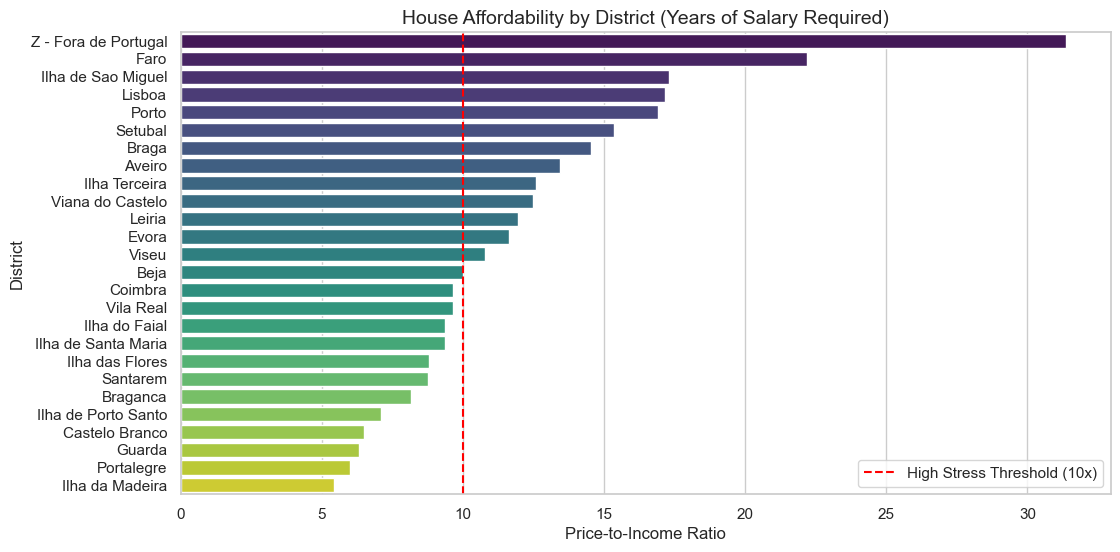

In [13]:
plt.figure(figsize=(12, 6))
avg_pti = merged.groupby('District')['PriceToIncome'].median().sort_values(ascending=False)
sns.barplot(x=avg_pti.values, y=avg_pti.index, palette='viridis')

plt.title('House Affordability by District (Years of Salary Required)', fontsize=14)
plt.xlabel('Price-to-Income Ratio')
plt.axvline(x=10, color='red', linestyle='--', label='High Stress Threshold (10x)')
plt.legend()
plt.show()